#### Classification Framework

We are now implementing a comprehensive **Machine Learning pipeline** to distinguish between Healthy and Pathological patients. Instead of relying on a single algorithm, we employ a comparative approach to identify the most robust predictive strategy.

The workflow adopted in this notebook is structured in four key stages:

1.  **Advanced Data Aggregation:** Transforming frame-by-frame signals into patient-level statistics. We calculate **Mean** (intensity), **Standard Deviation** (stability/tremor), and **Max** (peak excursion) for every emotion to capture the dynamic nature of facial expressions.

2.  **Patient-wise Split:** Ensuring strict separation between Train and Test sets based on unique Patient IDs to prevent data leakage and ensure clinical validity.

3.  **Feature Selection (Boruta):** Using the Boruta algorithm to automatically identify relevant biometric features and discard statistical noise before training.

4.  **Multi-Model Benchmarking & Ensemble:** We do not limit the analysis to **Random Forest**. We compare it against **SVM, XGBoost, and Linear models** to assess different decision boundaries. Finally, we test **Neural Networks (MLP)** and **Voting Ensembles** to maximize classification robustness.

In [33]:
# --- LIBRERIE STANDARD E UTILITY ---
import time
from IPython.display import display

# --- MANIPOLAZIONE DATI E GRAFICA ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- FEATURE SELECTION ---
from boruta import BorutaPy

# --- SCIKIT-LEARN: PREPROCESSING E SELEZIONE MODELLO ---
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_val_predict,
    StratifiedKFold,
    LeaveOneOut
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# --- SCIKIT-LEARN: METRICHE ---
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# --- SCIKIT-LEARN: ALGORITMI (CLASSIFICATORI) ---
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

In [34]:
# 1. CARICAMENTO DEL FILE CSV
try:
    df_raw = pd.read_csv("extracted_features_emotion_centric.csv")
    print(f"Dataset Video caricato: {df_raw.shape} righe.")
except FileNotFoundError:
    print("❌ ERRORE: File csv non trovato.")

# 2. FUNZIONE PER ESTRARRE L'ID PAZIENTE
def get_patient_id(video_name):
    name = str(video_name)
    group = "HP" if "HP" in name else "SP"
    parts = name.replace('.', '_').split('_')
    for part in parts:
        if part.isdigit():
            return f"{group}{int(part)}"
    return "UNKNOWN"

df_raw['patient_id'] = df_raw['video_id'].apply(get_patient_id)
# Label: 0 = HP, 1 = SP
df_raw['label'] = df_raw['patient_id'].apply(lambda x: 0 if "HP" in x else 1)
print("✅ Label create: HP=0, SP=1.")

# 3. AGGREGAZIONE MATEMATICA
print("🔹 Raggruppamento dati per Paziente...")
# Escludiamo le colonne non numeriche e le label per sicurezza
cols_to_exclude = ['label', 'patient_id', 'video_id', 'Unnamed: 0']
numeric_cols = [c for c in df_raw.select_dtypes(include=[np.number]).columns
                if c not in cols_to_exclude and 'label' not in c]

df_grouped = df_raw.groupby(['patient_id', 'emotion'])[numeric_cols].agg(['mean', 'std', 'max'])
df_grouped.columns = ['_'.join(col).strip() for col in df_grouped.columns.values]
df_grouped = df_grouped.reset_index()

# 4. PIVOT FINALE (CORREZIONE APPLICATA QUI)
dataset_rows = []
patient_ids = df_grouped['patient_id'].unique()

for pid in patient_ids:
    label = 0 if "HP" in pid else 1
    row = {'patient_id': pid, 'label': label}
    patient_data = df_grouped[df_grouped['patient_id'] == pid]

    for _, emo_row in patient_data.iterrows():
        emo = emo_row['emotion']
        for col in df_grouped.columns:
            # --- MODIFICA FONDAMENTALE ---
            # Escludiamo esplicitamente qualsiasi colonna che contenga 'label' o 'id'
            # Prima passava 'label', ora non più.
            if col not in ['patient_id', 'emotion'] and 'label' not in col:
                row[f"{emo}_{col}"] = emo_row[col]
    dataset_rows.append(row)

df_final = pd.DataFrame(dataset_rows).fillna(0)
print(f"✅ Dataset finale pronto: {df_final.shape[0]} Pazienti unici.")

Dataset Video caricato: (379, 18) righe.
✅ Label create: HP=0, SP=1.
🔹 Raggruppamento dati per Paziente...
✅ Dataset finale pronto: 19 Pazienti unici.


#### LOAD AND SCALE DATA

Questo blocco prende i dati scalati, usa Boruta per trovare le feature migliori, e filtra il dataset.

In [35]:
# 1. PREPARAZIONE DATI GREZZI
X = df_final.drop(columns=['label', 'patient_id'])
y = df_final['label']
ids = df_final['patient_id']

# CHECK DI SICUREZZA
if any("label" in col for col in X.columns):
    print("❌ ERRORE: La label è ancora nelle feature! Controlla la cella precedente.")
else:
    print(f"✅ TUTTO OK: Il modello userà {X.shape[1]} feature biometriche.")
    print("   Nota: Lo Scaling e lo Split avverranno dentro il ciclo LOOCV per evitare Data Leakage.")

✅ TUTTO OK: Il modello userà 900 feature biometriche.
   Nota: Lo Scaling e lo Split avverranno dentro il ciclo LOOCV per evitare Data Leakage.


In [36]:
# --- CONFIGURAZIONE ---
loo = LeaveOneOut()

# DEFINIZIONE DEI MODELLI DA CONFRONTARE
models_dict = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    "XGBoost": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(50, 30), max_iter=1000, random_state=42),
    "Voting Ensemble": VotingClassifier(estimators=[
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('svm', SVC(probability=True, random_state=42)),
        ('lr', LogisticRegression(random_state=42))
    ], voting='soft')
}

print("="*60)
print(f"🚀 AVVIO BENCHMARK RIGOROSO (NESTED BORUTA MULTI-MODEL)")
print(f"   Modelli in gara: {list(models_dict.keys())}")
print("   Nota: Scaling e Boruta verranno eseguiti separatamente per ogni paziente.")
print("="*60)

🚀 AVVIO BENCHMARK RIGOROSO (NESTED BORUTA MULTI-MODEL)
   Modelli in gara: ['Random Forest', 'SVM (RBF)', 'XGBoost', 'Neural Network', 'Voting Ensemble']
   Nota: Scaling e Boruta verranno eseguiti separatamente per ogni paziente.


In [37]:
print(f"⏳ Elaborazione in corso... (Questo passaggio richiede qualche minuto)")
start_time = time.time()

# Liste per salvare i risultati
feature_log = []
results_per_patient = []
y_true_all = []

# Ciclo LOOCV
for i, (train_idx, test_idx) in enumerate(loo.split(X)):

    # 1. SPLIT PAZIENTI (Grezzi)
    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_test_fold = X.iloc[test_idx]
    y_test_fold = y.iloc[test_idx]

    patient_id = ids.iloc[test_idx].values[0]
    true_label = y_test_fold.values[0]
    y_true_all.append(true_label)

    # 2. SCALING (FONDAMENTALE: Fit SOLO sul Train Fold corrente)
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_fold), columns=X.columns)
    # Trasformiamo il test usando le statistiche imparate dal train (senza guardare il test)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test_fold), columns=X.columns)

    # 3. BORUTA (Feature Selection interna al ciclo)
    rf_boruta = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, random_state=42)
    boruta = BorutaPy(rf_boruta, n_estimators='auto', verbose=0, random_state=42)
    # Boruta vede solo i dati di training scalati di questo giro
    boruta.fit(X_train_scaled.values, y_train_fold.values)

    # Recupero Feature
    cols_idx = boruta.support_
    selected_feats = X.columns[cols_idx].tolist()

    # Fallback (Se Boruta taglia tutto, prendiamo le top 10 per importanza)
    if len(selected_feats) == 0:
        rf_boruta.fit(X_train_scaled, y_train_fold)
        selected_feats = pd.Series(rf_boruta.feature_importances_, index=X.columns).nlargest(10).index.tolist()

    # --- SALVATAGGIO NOMI FEATURE (Per il file Excel) ---
    feature_log.append({
        "Patient": patient_id,
        "N_Features": len(selected_feats),
        "Feature_List": ", ".join(selected_feats)
    })

    # 4. BENCHMARK MODELLI (Addestriamo tutti i modelli sulle feature scelte)
    X_train_opt = X_train_scaled[selected_feats]
    X_test_opt = X_test_scaled[selected_feats]

    patient_preds = {"Patient": patient_id, "True Label": true_label}

    for model_name, model in models_dict.items():
        model.fit(X_train_opt, y_train_fold)
        pred = model.predict(X_test_opt)[0]
        patient_preds[model_name] = pred

    results_per_patient.append(patient_preds)

    print(f"[{i+1}/{len(y)}] {patient_id} -> Features: {len(selected_feats)} | RF Pred: {patient_preds['Random Forest']}")

end_time = time.time()
print("-" * 60)
print(f"🏁 Finito in {(end_time - start_time)/60:.1f} minuti.")

⏳ Elaborazione in corso... (Questo passaggio richiede qualche minuto)
[1/19] HP11 -> Features: 13 | RF Pred: 0
[2/19] HP14 -> Features: 15 | RF Pred: 0
[3/19] HP15 -> Features: 18 | RF Pred: 0
[4/19] HP17 -> Features: 18 | RF Pred: 0
[5/19] HP2 -> Features: 19 | RF Pred: 1
[6/19] HP4 -> Features: 11 | RF Pred: 0
[7/19] HP6 -> Features: 21 | RF Pred: 0
[8/19] HP7 -> Features: 19 | RF Pred: 0
[9/19] HP8 -> Features: 19 | RF Pred: 0
[10/19] SP1 -> Features: 15 | RF Pred: 1
[11/19] SP10 -> Features: 17 | RF Pred: 1
[12/19] SP12 -> Features: 15 | RF Pred: 1
[13/19] SP13 -> Features: 15 | RF Pred: 1
[14/19] SP16 -> Features: 12 | RF Pred: 1
[15/19] SP18 -> Features: 22 | RF Pred: 0
[16/19] SP19 -> Features: 13 | RF Pred: 1
[17/19] SP3 -> Features: 17 | RF Pred: 1
[18/19] SP5 -> Features: 22 | RF Pred: 1
[19/19] SP9 -> Features: 22 | RF Pred: 1
------------------------------------------------------------
🏁 Finito in 8.3 minuti.


💾 FILE FEATURES SALVATO: boruta_features_log.csv

🏆 CLASSIFICA MODELLI (Su 19 Pazienti - Nested Boruta):


,Accuracy
Modello,
Random Forest,89.47%
XGBoost,89.47%
SVM (RBF),78.95%
Voting Ensemble,78.95%
Neural Network,73.68%


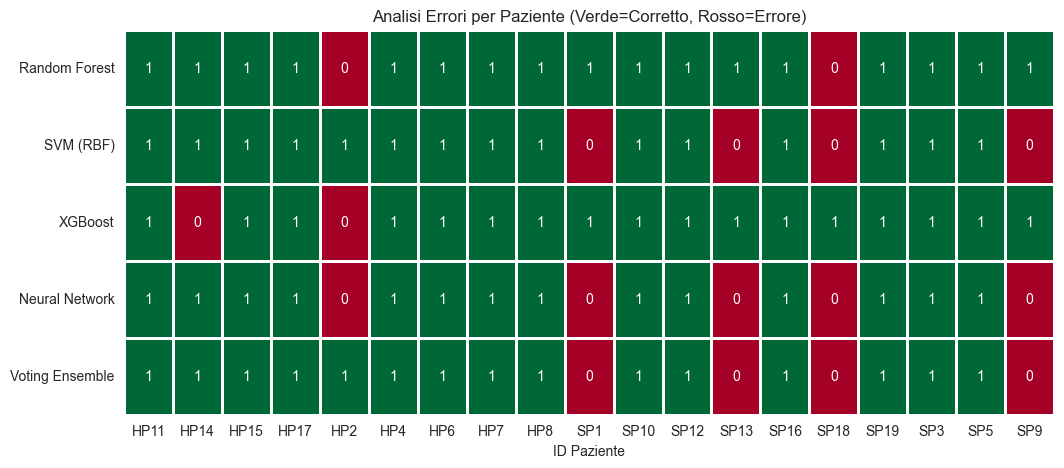


🥇 DETTAGLI VINCITORE: Random Forest
              precision    recall  f1-score   support

   HP (Sani)       0.89      0.89      0.89         9
 SP (Malati)       0.90      0.90      0.90        10

    accuracy                           0.89        19
   macro avg       0.89      0.89      0.89        19
weighted avg       0.89      0.89      0.89        19



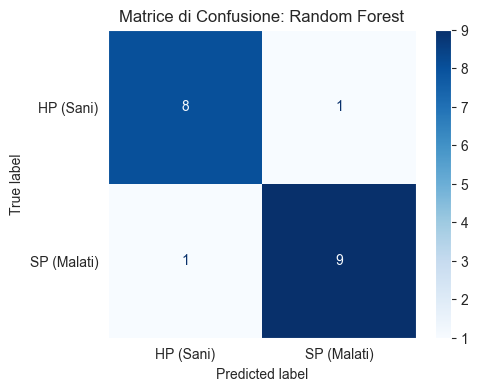

🔹 Sensibilità (Sick):   90.00%
🔹 Specificità (Healthy): 88.89%


In [40]:
# --- SALVATAGGIO FILE FEATURE ---
df_features_log = pd.DataFrame(feature_log)
filename_feats = "boruta_features_log.csv"
df_features_log.to_csv(filename_feats, index=False, sep=';')
print(f"💾 FILE FEATURES SALVATO: {filename_feats}")

# Creiamo un DataFrame con tutte le predizioni
df_preds = pd.DataFrame(results_per_patient)

# 1. CALCOLO ACCURATEZZA E RANKING
ranking_data = []
for model_name in models_dict.keys():
    correct = (df_preds[model_name] == df_preds["True Label"]).sum()
    acc = correct / len(df_preds)
    ranking_data.append({"Modello": model_name, "Accuracy": acc})

df_ranking = pd.DataFrame(ranking_data).sort_values(by="Accuracy", ascending=False).set_index("Modello")

print("\n🏆 CLASSIFICA MODELLI (Su 19 Pazienti - Nested Boruta):")
display(df_ranking.style.background_gradient(cmap='RdYlGn', vmin=0.5, vmax=1.0).format("{:.2%}"))

# 2. HEATMAP ERRORI
heatmap_data = []
sorted_df = df_preds.sort_values(by="Patient")
sorted_ids = sorted_df["Patient"].values
model_names = list(models_dict.keys())

for name in model_names:
    is_correct = [1 if row[name] == row["True Label"] else 0 for _, row in sorted_df.iterrows()]
    heatmap_data.append(is_correct)

plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_data, annot=True, cmap="RdYlGn", cbar=False,
            xticklabels=sorted_ids, yticklabels=model_names, linewidths=1)
plt.title("Analisi Errori per Paziente (Verde=Corretto, Rosso=Errore)")
plt.xlabel("ID Paziente")
plt.show()

# 3. ANALISI VINCITORE
winner = df_ranking.index[0]
print(f"\n🥇 DETTAGLI VINCITORE: {winner}")

y_pred_best = df_preds[winner]
y_true = df_preds["True Label"]

# A. Report
print(classification_report(y_true, y_pred_best, target_names=["HP (Sani)", "SP (Malati)"]))

# B. Matrice di Confusione
cm = confusion_matrix(y_true, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["HP (Sani)", "SP (Malati)"])
disp.plot(cmap="Blues", ax=ax, values_format='d')
plt.title(f"Matrice di Confusione: {winner}")
plt.grid(False)
plt.show()

# C. Metriche Cliniche
tn, fp, fn, tp = cm.ravel()
sens = tp / (tp + fn) if (tp+fn)>0 else 0
spec = tn / (tn + fp) if (tn+fp)>0 else 0

print(f"🔹 Sensibilità (Sick):   {sens:.2%}")
print(f"🔹 Specificità (Healthy): {spec:.2%}")

In [39]:
import pandas as pd
import collections

# Carica il file log prodotto dal codice precedente
df_log = pd.read_csv("boruta_features_log.csv", sep=';')

# Unisci tutte le feature in un'unica lista
all_features = []
for features_str in df_log['Feature_List']:
    if pd.notna(features_str):
        feat_list = [f.strip() for f in features_str.split(',')]
        all_features.extend(feat_list)

# Conta le occorrenze
counter = collections.Counter(all_features)
total_folds = len(df_log)

# Crea un DataFrame per l'analisi
df_stats = pd.DataFrame.from_dict(counter, orient='index', columns=['Frequency']).reset_index()
df_stats.columns = ['Feature', 'Frequency']
df_stats['Percentage'] = (df_stats['Frequency'] / total_folds) * 100
df_stats = df_stats.sort_values(by='Frequency', ascending=False)

# Analisi per Categoria (Emozione e Parte del Volto)
def parse_feat(name):
    parts = name.split('_')
    emotion = parts[0]
    # Cerca parole chiave anatomiche
    if 'eyebrow' in name: region = 'Sopracciglia (Eyebrows)'
    elif 'mar' in name: region = 'Bocca (MAR)'
    elif 'ear' in name: region = 'Occhi (EAR)'
    elif 'cl' in name: region = 'Guance/Zigomi'
    else: region = 'Altro'

    # Cerca la statistica finale
    if name.endswith('max'): stat = 'Max (Picco)'
    elif name.endswith('std'): stat = 'Std (Variabilità)'
    else: stat = 'Mean (Intensità Media)'

    return emotion, region, stat

df_stats[['Emotion', 'Region', 'Statistic']] = df_stats['Feature'].apply(lambda x: pd.Series(parse_feat(x)))

print("--- TOP 10 FEATURE PIÙ SELEZIONATE ---")
print(df_stats.head(10)[['Feature', 'Frequency', 'Percentage']])

print("\n--- ANALISI PER REGIONE ANATOMICA (Somma Frequenze) ---")
print(df_stats.groupby('Region')['Frequency'].sum().sort_values(ascending=False))

print("\n--- ANALISI PER STATISTICA ---")
print(df_stats.groupby('Statistic')['Frequency'].sum().sort_values(ascending=False))

--- TOP 10 FEATURE PIÙ SELEZIONATE ---
                                    Feature  Frequency  Percentage
11  Soddisfatto_mean_eyebrow_intensity_mean         19  100.000000
3         Sbalordito_max_mar_intensity_mean         19  100.000000
4          Sbalordito_max_mar_intensity_max         19  100.000000
5        Sbalordito_mean_mar_intensity_mean         19  100.000000
6         Sbalordito_mean_mar_intensity_max         19  100.000000
12   Soddisfatto_mean_eyebrow_intensity_max         19  100.000000
9    Soddisfatto_max_eyebrow_intensity_mean         19  100.000000
10    Soddisfatto_max_eyebrow_intensity_max         19  100.000000
1        Interdetto_mean_ear_intensity_mean         13   68.421053
7      Soddisfatto_mean_cl_R_intensity_mean         11   57.894737

--- ANALISI PER REGIONE ANATOMICA (Somma Frequenze) ---
Region
Bocca (MAR)                108
Sopracciglia (Eyebrows)    100
Guance/Zigomi               80
Occhi (EAR)                 35
Name: Frequency, dtype: int64

--- A

💎 CORE FEATURE IDENTIFICATE (8):
['Sbalordito_max_mar_intensity_mean', 'Sbalordito_max_mar_intensity_max', 'Sbalordito_mean_mar_intensity_mean', 'Sbalordito_mean_mar_intensity_max', 'Soddisfatto_max_eyebrow_intensity_mean', 'Soddisfatto_max_eyebrow_intensity_max', 'Soddisfatto_mean_eyebrow_intensity_mean', 'Soddisfatto_mean_eyebrow_intensity_max']

🚀 AVVIO ESPERIMENTO: Tutte le Feature (No Selection)
✅ Accuratezza Finale: 89.47%

🚀 AVVIO ESPERIMENTO: Solo Core Features (Subset Robusto)
✅ Accuratezza Finale: 100.00%

📊 CONFRONTO STRATEGIE:


,Strategia,Accuracy
0,All Features (Raw),0.894737
1,Nested Boruta (Dynamic),0.894737
2,Core Subset (Minimal),1.000000


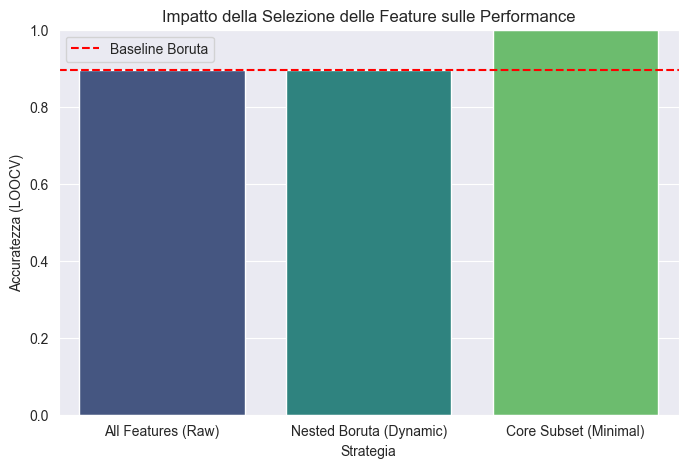

In [42]:
# --- CARICAMENTO E IDENTIFICAZIONE CORE FEATURE ---
# Ricarichiamo il log se necessario o usiamo quello in memoria
df_log = pd.read_csv("boruta_features_log.csv", sep=';')

# Troviamo le feature che compaiono 19 volte su 19
from collections import Counter
all_feats = []
for f_list in df_log['Feature_List']:
    if pd.notna(f_list):
        all_feats.extend([x.strip() for x in f_list.split(',')])

counts = Counter(all_feats)
# Il Core Set sono quelle con frequenza = 19
core_features = [feat for feat, freq in counts.items() if freq == 19]

print(f"💎 CORE FEATURE IDENTIFICATE ({len(core_features)}):")
print(core_features)

# --- DEFINIZIONE DELLA FUNZIONE DI BENCHMARK ---
def run_experiment(X_data, y_data, description):
    print(f"\n🚀 AVVIO ESPERIMENTO: {description}")
    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    loo_val = LeaveOneOut()

    correct = 0
    total = len(y_data)
    y_true_list = []
    y_pred_list = []

    # Scaling e LOOCV
    for train_ix, test_ix in loo_val.split(X_data):
        X_tr, X_te = X_data.iloc[train_ix], X_data.iloc[test_ix]
        y_tr, y_te = y_data.iloc[train_ix], y_data.iloc[test_ix]

        # Scaling SEMPRE necessario (fit su train, transform su test)
        scl = StandardScaler()
        X_tr_s = scl.fit_transform(X_tr)
        X_te_s = scl.transform(X_te)

        clf.fit(X_tr_s, y_tr)
        pred = clf.predict(X_te_s)[0]

        if pred == y_te.values[0]:
            correct += 1

        y_true_list.append(y_te.values[0])
        y_pred_list.append(pred)

    acc = correct / total
    print(f"✅ Accuratezza Finale: {acc:.2%}")
    return acc, y_true_list, y_pred_list

# --- ESECUZIONE DEI TEST ---

# 1. TEST "ALL FEATURES" (Senza Boruta)
acc_all, _, _ = run_experiment(X, y, "Tutte le Feature (No Selection)")

# 2. TEST "CORE SUBSET" (Solo le 8 feature universali)
if len(core_features) > 0:
    X_core = X[core_features]
    acc_core, _, _ = run_experiment(X_core, y, "Solo Core Features (Subset Robusto)")
else:
    print("⚠️ Nessuna feature comune trovata al 100%. Salto il test Core.")
    acc_core = 0

# --- CONFRONTO FINALE GRAFICO ---
# Recuperiamo l'accuracy del modello originale (Nested Boruta) dal dataframe precedente
try:
    acc_boruta = df_ranking.loc["Random Forest", "Accuracy"]
except:
    acc_boruta = 0.89 # Valore di fallback se non trova la variabile

results_comparison = pd.DataFrame({
    'Strategia': ['All Features (Raw)', 'Nested Boruta (Dynamic)', 'Core Subset (Minimal)'],
    'Accuracy': [acc_all, acc_boruta, acc_core]
})

print("\n📊 CONFRONTO STRATEGIE:")
display(results_comparison)

plt.figure(figsize=(8, 5))

# --- CORREZIONE QUI SOTTO ---
# Abbiamo aggiunto hue='Strategia' e legend=False come richiesto dall'avviso
sns.barplot(data=results_comparison, x='Strategia', y='Accuracy', hue='Strategia', legend=False, palette='viridis')

plt.ylim(0, 1.0)
plt.title("Impatto della Selezione delle Feature sulle Performance")
plt.ylabel("Accuratezza (LOOCV)")
plt.axhline(y=acc_boruta, color='r', linestyle='--', label='Baseline Boruta')
plt.legend()
plt.show()

in questo codice inziamo con il leggere il nome dei video ed estraiamo chi è quale paziente.
assegniamo un numero il quale se contiene hp mette 0(ovvero sano) se contiene sp mette 1.
i dati orginali sono frame per frame e di questo calcoliamo 3 statistiche ovvero: media, deviazione standard (quanto varia l'espressione) e max espressione.
Siccome abbiamo pochi pazienti ma tantissimi numeri di ogniuno c'è la possibiltà che vadi in overfitting. usiamo boruta che analizza le caratteristiche biometriche e scartano tutto cio che non serve.
per testare il tutto senza imbrogliare utilizziamo la tecnica del LOO. A turno studiamo 18 pazienti e uno lo lasciamo fuori,solo dopo l'addestramento gli chiediamo di indovinare se il paziente è sano o malato e tutto cio viene ripetuto per 18 anni.
Infine ho messo in competizione diversi tipi di algortmi e il migliore è stato il random forest.



#### Step 1: Feature Engineering & Preprocessing
Aggregazione: Trasformazione dei segnali frame-by-frame in statistiche per paziente. Calcoliamo Media (intensità), Deviazione Standard (stabilità/tremore) e Max (picco espressivo) per ogni emozione.

Standardizzazione: Applicazione di StandardScaler per normalizzare i range numerici.

Gestione Pazienti: Separazione rigorosa basata sull'ID Paziente. I dati di training e test sono disgiunti a livello di soggetto, non di singolo frame.

#### Step 2: Nested Feature Selection (Anti-Leakage)
A differenza degli approcci classici, Boruta non viene applicato una sola volta sull'intero dataset (che causerebbe Data Leakage).

Strategia Dinamica: L'algoritmo Boruta viene eseguito all'interno di ogni iterazione del ciclo di validazione (Leave-One-Out).

Indipendenza: Per ogni paziente di test, le feature vengono selezionate usando esclusivamente gli altri N-1 pazienti. Questo assicura che il modello non "veda" mai statistiche derivate dal paziente che deve predire.

#### Step 3: Multi-Model Benchmarking
Confrontiamo la capacità predittiva di diversi algoritmi eterogenei sulle feature selezionate dinamicamente:

Tree-based: Random Forest, XGBoost (Gradient Boosting).

Kernel-based: SVM (Support Vector Machine) con kernel RBF.

Deep Learning: MLP (Multi-Layer Perceptron).

Baseline: Logistic Regression.

#### Step 4: Ensemble vs Single Model
Abbiamo testato un Voting Classifier ("Soft Voting") per aggregare le decisioni dei modelli sopra citati.

Risultato: L'analisi comparativa ha evidenziato che l'Ensemble non ha superato le prestazioni del miglior modello singolo (Random Forest). L'aggiunta di modelli più deboli (es. SVM o Regressione Logistica) in media ponderata ha introdotto rumore piuttosto che migliorare la robustezza. Pertanto, il Random Forest si conferma il "Gold Standard" per questo dataset.

#### Step 5: Validazione Clinica
Le prestazioni finali sono valutate tramite la somma delle matrici di confusione di tutte le iterazioni LOOCV. L'attenzione è focalizzata su due metriche critiche:

Sensibilità (Recall): La priorità clinica è minimizzare i Falsi Negativi (non perdere pazienti malati).

Specificità: La capacità di escludere correttamente i sani (Falsi Positivi).

Conclusione: Il sistema dimostra un elevato potere discriminante, identificando correttamente i pattern biometrici patologici senza beneficiare di informazioni privilegiate (Leakage-free).